# Theory

Background for [qiskit-qaoa-knapsack-domi](../README.md): how the knapsack is
encoded as a QUBO, converted to an Ising Hamiltonian and solved by digitized
quantum annealing, and what the Lagrange multipliers `LAM1` and `LAM2` actually
do.

The maths renders on GitHub. All numbers quoted here come from the reference
instance `KnapsackProblem.random(15, seed=38)` run on `ibm_kingston` — see
[example_output.md](example_output.md) for that run's full log.

---

# Knapsack problem as a QUBO → Ising → quantum annealing

## 1. The optimization problem

With item values $v_i$ (`values`), weights $w_i$ (`weights`) and capacity $C$ (`CAPACITY`):

$$
\max_{x\in\{0,1\}^N}\ \sum_{i=0}^{N-1} v_i\,x_i
\qquad\text{subject to}\qquad
\sum_{i=0}^{N-1} w_i\,x_i \;\le\; C .
$$

A quantum annealer minimizes energy, so we flip the sign of the objective and minimize $-\sum_i v_i x_i$.

The reference instance (`KnapsackProblem.random(15, seed=38)`) has $C=68$ and DP optimum $272$.

---

## 2. Two ways to encode the inequality — and which one runs

A QUBO can only encode **equalities** or **soft penalties**. Both encodings are described below; **only the second one is implemented in this package**.

### (a) Slack variables — present but commented out

Turn "$\le$" into "$=$" by adding a slack $S\in\{0,\dots,C\}$ stored in a bounded log-encoding,

$$
\sum_i w_i x_i + S = C,\qquad
S=\sum_{k=0}^{K-1} a_k\,s_k,\quad
a_k = 2^{k}\ (k<K-1),\quad
a_{K-1}=C-\bigl(2^{K-1}-1\bigr),\quad K=\lfloor\log_2 C\rfloor+1,
$$

with a single penalty weight $P=\max_i v_i+1$. Correctness is then **guaranteed by construction** — no tuning needed — at the cost of $K\approx\log_2 C$ extra qubits ($K=7$ here, so $n=22$).

This route is not implemented in the package. It is the right one for large $N$, where the full $2^N$ verification used below is not available.

### (b) Soft penalty — **this is what runs**

No slack, no extra qubits: $n=N=15$. The constraint is folded into the objective as an augmented Lagrangian,

$$
E(x) \;=\; -\alpha\,V(x) \;+\; \lambda_1\,W(x) \;+\; \lambda_2\,\bigl(W(x)-C\bigr)^2,
\qquad V=\sum_i v_i x_i,\quad W=\sum_i w_i x_i,
$$

with `ALPHA`, `LAM1`, `LAM2` chosen by `tune_penalties()`. Feasibility is **not** guaranteed here — it depends entirely on those three coefficients, which is why `check_ground_state()` verifies that the minimum of $E$ is feasible before the circuit is built.

Values used in the run: `ALPHA = 2.0`, `LAM1 = 6.20`, `LAM2 = 0.179`.

---

## 3. The QUBO coefficients

Using $x_i^2=x_i$ and dropping the constant $\lambda_2 C^2$:

$$
\text{lin}_i = -\alpha v_i + \lambda_1 w_i + \lambda_2\bigl(w_i^2 - 2C w_i\bigr),
\qquad
\text{quad}_{ij} = 2\lambda_2\,w_i w_j \quad (i<j).
$$

The couplings are **all-to-all**: $\text{quad}_{ij}\propto w_iw_j$ is nonzero for every pair, so a full layer costs $N(N-1)/2 = 105$ RZZ gates.

---

## 4. Coupler pruning (`PRUNE_KEEP`) — a deliberate depth/exactness trade

The couplings are all-to-all, so the two-qubit gate count grows as
$\mathcal{O}(N^2\cdot\texttt{STEPS})$ and quickly exceeds what the device can hold
coherently. `PRUNE_KEEP` caps it by keeping only the largest-magnitude couplings:

```python
prune_keep = 0.5      # keeps 55 of 105 RZZ  ->  766 physical 2q gates
```

**The target is a gate budget, not a fraction.** With $\approx 4.6$ physical 2q gates
per logical RZZ on heavy-hex, a budget $G$ implies

$$
\texttt{PRUNE\_KEEP} \;\approx\; \min\!\left(1,\;
\frac{G}{4.6\cdot \tfrac{N(N-1)}{2}\cdot \texttt{STEPS}}\right)
$$

For $G=1200$, `STEPS = 3`: $N=12 \to 1.0$, $N=15 \to 0.83$, $N=18 \to 0.57$,
$N=20 \to 0.46$, $N=25 \to 0.29$.

### What pruning actually does to the sampled distribution

Pruning changes the cost function, so the argmin of the **pruned** model is generally not
the knapsack optimum. That turns out to be the wrong thing to measure. A shallow anneal
at $\Delta t = 2$ is nowhere near converged onto its ground state, so where the minimum
sits says little about where the samples land. What matters is the **rank of the optimum
in the sampled distribution**, because the selection step is classical — out of 300 000
shots, the best *feasible* bitstring is kept and verified against the constraint.

Ranks from a noiseless statevector simulation of the circuit that actually runs
(`seed 38`, `STEPS = 3`, `T = 6.0`, `ALPHA = 2.0`, `LAM1 = 6.20`, `LAM2 = 0.179`):

| `prune_keep` | RZZ kept | rank of optimum | $P(\text{opt})$ | vs uniform |
|---|---|---|---|---|
| 1.00 | 105 | 152 | 0.0770 % | 25× |
| **0.50** | **55** | **39** | **0.3089 %** | **101×** |
| 0.25 | 27 | 291 | 0.0432 % | 14× |
| 0.20 | 22 | 231 | 0.0535 % | 18× |
| 0.10 | 14 | 318 | 0.0212 % | 7× |

At `prune_keep = 0.5` the pruned circuit concentrates on the optimum **four times more
strongly** than the complete one — while using half the RZZ, and therefore decohering
less on hardware. Pruning here is not a compromise; on this instance it is an
improvement, and the measured hardware run recovered the exact optimum.

### But lower it with care — the good values are not a smooth range

The ranks above are not monotone in `prune_keep`, and the bad regions **move with the
penalties**. Rank of the optimum around the 0.5–0.8 band:

| `LAM1` | `LAM2` | 0.80 | 0.75 | 0.70 | 0.65 | 0.60 | 0.55 | 0.50 |
|---|---|---|---|---|---|---|---|---|
| 6.20 | 0.179 | 223 | 2620 | 2761 | 190 | 28 | 24 | 39 |
| 5.60 | 0.150 | 252 | 4011 | 1277 | 134 | 23 | 25 | 41 |
| 6.80 | 0.220 | 254 | 3370 | 2571 | 187 | 26 | 24 | 41 |
| 6.20 | 0.100 | 44 | 51 | 80 | 162 | **805** | 64 | 61 |
| 6.20 | 0.300 | 766 | 1089 | 178 | 60 | 16 | 54 | 101 |

No single value of `prune_keep` is inherently broken. At `LAM2 = 0.179` the collapse is at
0.70–0.75; at `LAM2 = 0.100` those are fine and 0.60 collapses instead. `LAM1` and `LAM2`
reshape the landscape, so they and `prune_keep` have to be judged together, never in
isolation.

### What a fine sweep shows

Sweeping `prune_keep` from 1.00 down to 0.10 in steps of 0.02, with penalties tuned
separately for each instance ($N=15$, `STEPS = 3`, `T = 6.0`):

| instance | behaviour | in top 300 |
|---|---|---|
| `seed 38` | flat ~150 down to 0.80, **collapse across 0.78–0.68** (ranks 987–9542), best 16–39 over 0.58–0.48, degrades below 0.44 | 29 / 46 |
| `seed 7` | flat 5–9 from 1.00 to 0.50, gradual decay, unusable below 0.26 | 38 / 46 |
| `seed 21` | rank 1 from 1.00 to 0.46, mild decay after | 46 / 46 |

Three things follow, none of them obvious in advance:

**The bad region, when it exists, is wide and contiguous** — on `seed 38` it spans 0.10 in
`prune_keep`, not a narrow spike. **Its location is instance-specific**, and on two of the
three instances it does not exist at all. And **quality degrades below roughly 0.3–0.4** on
every instance tested, which is the one robust boundary.

`prune_keep` is also quantized: it selects an integer number of couplings, so on this
instance 0.12 and 0.10 both leave 14 couplings and compile to the same circuit. Sweeping
more finely than about 1/105 buys nothing.

### A halving ladder does not help

The ladder 1.0 → 0.5 → 0.25 → 0.125 is a natural thing to reach for, but the data does not
support it:

| instance | 1.0 | 0.5 | 0.25 | 0.125 |
|---|---|---|---|---|
| `seed 38` | 158 | **39** | 284 | 309 |
| `seed 7` | 7 | **9** | 392 | 3775 |
| `seed 21` | 1 | **1** | 27 | 4 |

The third rung is already unusable on two of the three instances. Halving neither avoids
the collapse bands — it steps over `seed 38`'s by luck, not by design — nor tracks the
degradation boundary, which sits between the second and third rung and is not a power of
two. What the ladder does reliably is halve the gate count, and it happens that the
second rung, `prune_keep = 0.5`, is good on all three instances.

**So: 1.0 and 0.5 are both safe starting points, and 0.5 is the better one — it is at
least as good on all three instances and uses half the RZZ. Below 0.5, verify the
specific value; do not extrapolate.** The verification worth doing, when $N$ allows the
$2^N$ enumeration, is the rank of the optimum in the simulated distribution — not the
argmin of the pruned cost.

### One thing pruning is *not*

It is not merely deleting redundant gates. In `qubo_to_ising` every coupling contributes
to two linear biases as well,

```python
h[j] += -q / 4
h[l] += -q / 4
J[(j, l)] = q / 4
```

so dropping it removes those contributions too and changes the normalizer $s$. Measured
at `prune_keep = 0.5` on this instance: $\max_j|\Delta h_j| = 0.86$ in normalized units
where the maximum is 1.0 by construction, and $s$ moves from 176.7 to 157.0. The pruned
circuit implements a genuinely different Ising model — which is precisely why it can
sample *better* than the complete one, not merely cheaper.

`check_ground_state()` operates on the **unpruned** cost, so it validates the *tuning*,
not the *circuit*. That is still worth checking; it is just a different question.

### Two ways to buy back the gates without pruning

**(a) Mean-field absorption.** Instead of discarding a dropped coupling, fold its
first-order effect into the linear terms ($\langle x_j\rangle \approx \tfrac12$):

```python
else:
    lin[i] += q * 0.5
    lin[j] += q * 0.5          # instead of dropping q entirely
```

Free — no extra gates. Measured on this instance at `PRUNE_KEEP = 0.5`, this pulls the
pruned ground state from *value 328 / weight 94* back to *value 237 / weight 67*, i.e.
back **inside the capacity**. Still not the optimum, but the sampler is now concentrated
in the feasible region instead of outside it, which is exactly what post-selection wants.

**(b) A linear SWAP network instead of generic routing.** The odd–even transposition
network realizes *all* $N(N-1)/2$ couplings on a qubit path in $N$ layers, at ~3 two-qubit
gates per pair (the ZZ merges into the SWAP), versus the ~4.6 the transpiler currently
spends per *kept* pair:

| $N$ | pairs | SWAP-network 2q gates (`STEPS = 3`, **no pruning**) |
|---|---|---|
| 12 | 66 | 594 |
| 15 | 105 | **945** |
| 18 | 153 | 1377 |
| 20 | 190 | 1710 |

At $N=15$ that is the **complete** model for 945 gates — under the 1200 budget and cheaper
than today's pruned 766-gate circuit is per coupling. This is the option worth trying first;
pruning then only becomes necessary from $N\approx 18$ up.

---

## 5. QUBO → Ising Hamiltonian

Quantum hardware works with spins $Z_j\in\{+1,-1\}$, so substitute

$$
x_j=\frac{1-Z_j}{2}
\qquad\bigl(x_j=0\leftrightarrow Z_j=+1,\quad x_j=1\leftrightarrow Z_j=-1\bigr).
$$

Collecting terms gives

$$
H=\sum_j h_j\,Z_j+\sum_{j<l} J_{jl}\,Z_jZ_l+\text{const},
\qquad
h_j=-\tfrac12\,\text{lin}_j\;-\;\tfrac14\!\!\sum_{l\,:\,(j,l)\in\text{quad}}\!\!\text{quad}_{jl},
\qquad
J_{jl}=\tfrac14\,\text{quad}_{jl}.
$$

The constant only shifts all energies equally, so it is dropped.

**Normalization.** Every $h_j,J_{jl}$ is divided by $\text{scale}=\max(|h_j|,|J_{jl}|)$ so the problem energy scale is $\mathcal{O}(1)$, comparable to the mixer. Without this the penalty would dominate the mixer and the anneal would not be adiabatic. Decoding reads bits directly, so rescaling is harmless — but note it also means `ALPHA` is purely a scale factor: $(\alpha,\lambda_1,\lambda_2)$ and $(k\alpha,k\lambda_1,k\lambda_2)$ give a bit-identical circuit.

---

## 6. Digitized (Trotterized) quantum annealing — no optimizer

Two Hamiltonians:

$$
H_M=-\sum_j X_j \quad(\text{mixer, ground state }|+\rangle^{\otimes n}),
\qquad
H_P=\sum_j h_j Z_j+\sum_{j<l} J_{jl} Z_jZ_l \quad(\text{problem}).
$$

Start in $|+\rangle^{\otimes n}$ and interpolate linearly from mixer to problem, $H(s)=(1-s)H_M+sH_P$, discretized into `STEPS` Trotter steps with $\Delta t=T/\texttt{STEPS}$ and a **midpoint** schedule

$$
s_p=\frac{p+\tfrac12}{\texttt{STEPS}},\qquad p=0,\dots,\texttt{STEPS}-1,
$$

$$
U_p=\underbrace{e^{-i\,\Delta t\,s_p\,H_P}}_{\text{problem layer}}\;
     \underbrace{e^{-i\,\Delta t\,(1-s_p)\,H_M}}_{\text{mixer layer}} .
$$

The midpoint is deliberate. With the naive $s_p=p/\texttt{STEPS}$ the last mixer angle is zero, the final problem layer is diagonal and therefore invisible to a Z-basis measurement — at `STEPS = 1` the output distribution would be exactly uniform regardless of the coefficients.

There is **no classical optimizer** — the schedule is fixed, exactly like a D-Wave anneal. `STEPS` / `T` play the role of `num_sweeps` / anneal time. The run uses `STEPS = 3`, `T = 6.0`, i.e. $\Delta t = 2.0$.

---

## 7. Why the $R_{ZZ}$ (and $R_Z$) gates commute — and why that matters

Every term in $H_P$ is **diagonal** (built only from $Z$ and $Z\!\otimes\! Z$). Diagonal operators all commute:

$$
[\,Z_a,\,Z_bZ_c\,]=0,\qquad [\,Z_aZ_b,\,Z_cZ_d\,]=0 .
$$

Therefore the exponential of the *whole* problem layer factorizes **without any Trotter error**:

$$
e^{-i t H_P}=\prod_j e^{-i t\,h_j Z_j}\;\prod_{j<l} e^{-i t\,J_{jl} Z_jZ_l}
\qquad(\text{exact}).
$$

Two useful consequences:

- **Order-independence.** Because the $R_{ZZ}$ factors commute, they can be applied in *any* order (and reordered/parallelized freely by the transpiler) — the resulting unitary is identical.
- **The only approximation is between layers.** The mixer terms $-X_j$ likewise all commute with each other, so $e^{-i t H_M}=\prod_j e^{+itX_j}$ is also exact. The *sole* Trotter error comes from $[\,H_M,H_P\,]\neq 0$. That discretization error is the annealing granularity, controlled by `STEPS` — and it grows with $\Delta t$, which is why the tuner docs recommend keeping $\Delta t \lesssim 1.3$.

### Gate translations (what the code emits)

Using $R_Z(\theta)=e^{-i\theta Z/2}$, $R_{ZZ}(\theta)=e^{-i\theta\,Z\otimes Z/2}$, $R_X(\theta)=e^{-i\theta X/2}$:

$$
e^{-i t\,h_j Z_j}=R_Z(2 t\,h_j),\qquad
e^{-i t\,J_{jl} Z_jZ_l}=R_{ZZ}(2 t\,J_{jl}),\qquad
e^{+i t\,X_j}=R_X(-2 t).
$$

which is exactly

```python
qc.rz (2 * t_prob * h[j],   j)       # problem: single-Z
qc.rzz(2 * t_prob * J[j,l], j, l)    # problem: ZZ coupling (all mutually commuting)
qc.rx (-2 * t_mix,          j)       # mixer:  -X_j
```

with `t_prob = dt * s`, `t_mix = dt * (1 - s)` and `s = (p + 0.5) / STEPS`.

`ibm_kingston` has `rzz` in its native basis, but after routing an all-to-all layer onto heavy-hex the transpiler still emits SWAP-equivalent `cz`: 55 logical RZZ × 3 steps expanded to **766** two-qubit gates, i.e. ≈ 4.6 physical 2q gates per logical RZZ.

---

# Lagrange multipliers `LAM1` and `LAM2`

## 1. Where they come from

The original problem is **constrained**:

$$\max_{x\in\{0,1\}^N} \sum_i v_i x_i
\qquad\text{subject to}\qquad \sum_i w_i x_i \le C$$

A quantum circuit cannot do constrained optimization. The phase layer applies
$e^{-i\gamma H_C}$, where $H_C$ is a diagonal operator — it can assign a number
to every bitstring, but it cannot forbid any bitstring. The constraint therefore
has to be moved **into the objective**. That is what Lagrangian relaxation is for:

$$\mathcal{L}(x,\lambda) = -\alpha\underbrace{\sum_i v_i x_i}_{V(x)}
\;+\;\lambda_1\Bigl(\underbrace{\sum_i w_i x_i}_{W(x)} - C\Bigr)$$

The sign in front of $V$ is negative because the circuit looks for a **minimum**,
whereas the knapsack is a maximization problem.

The linear term alone is not enough — its minimum is always at a corner of the
cube (every item is either obviously worth taking or obviously not), and the
capacity is hit only by accident. A quadratic term is therefore added, giving the
**augmented Lagrangian**:

$$E(x) = -\alpha V(x) + \lambda_1 W(x) + \lambda_2\bigl(W(x)-C\bigr)^2$$

Strictly speaking only $\lambda_1$ is a Lagrange multiplier; $\lambda_2$ is a
penalty coefficient. In practice they are tuned together and behave as a pair.

---

## 2. What $\lambda_1$ does — the shadow price of capacity

$\lambda_1/\alpha$ is the **exchange rate between value and weight**. Item $i$ is
favoured by the linear term exactly when

$$-\alpha v_i + \lambda_1 w_i < 0
\qquad\Longleftrightarrow\qquad
\frac{v_i}{w_i} > \frac{\lambda_1}{\alpha}$$

So $\lambda_1/\alpha$ is a **threshold on value density**. Items above the
threshold get taken, items below it get left behind.

This is not an arbitrary number. Duality theory says that the optimal multiplier
for the LP relaxation of the knapsack is precisely the density of the **break
item** — the one on which the capacity runs out when filling in order of
decreasing density.

### For the reference N=15 instance (`seed 38`, $C = 68$)

Filling by density $v_i/w_i$:

| rank | item | $v_i$ | $w_i$ | $v_i/w_i$ | cumul. weight |
|---|---|---|---|---|---|
| 1 | 12 | 43 | 3 | 14.33 | 3 |
| 2 | 3 | 53 | 9 | 5.89 | 12 |
| 3 | 4 | 51 | 11 | 4.64 | 23 |
| 4 | 10 | 28 | 8 | 3.50 | 31 |
| 5 | 2 | 32 | 11 | 2.91 | 42 |
| 6 | 13 | 47 | 17 | 2.76 | **59** |
| — | 9 | 34 | 13 | **2.615** | ← break item (13 > 68 − 59) |
| 8 | 1 | 31 | 12 | 2.58 | |
| 9 | 8 | 49 | 19 | 2.58 | |
| 10 | 0 | 45 | 19 | 2.37 | |

$$\lambda^\star = 2.615$$

The six items above the break have value 254 at weight 59; the LP bound is
$254 + 9\cdot 2.615 = 277.5$, while the DP optimum is **272**. Unlike the earlier
instance, the LP relaxation here is **not** integral — the gap of 5.5 means the
linear threshold alone does not hit the optimum and the quadratic term has real
work to do.

Compared with what `tune_penalties()` found:

| quantity | value |
|---|---|
| $\lambda_1/\alpha$ (`LAM1 = 6.20`, `ALPHA = 2.0`) | 3.100 |
| ratio to $\lambda^\star$ | **1.19×** |

So the tuner, independently and purely by maximizing $P(\text{opt})$ in
simulation, arrived at the shadow price from LP duality — and landed exactly in
the 1.09–1.38× window on which the automatic `auto_window=(0.7, 1.7)` is built.
That is a strong check that it is searching for a meaningful quantity, and at the
same time a practical tip: a sensible starting guess for $\lambda_1/\alpha$ is
the density of the break item, not a random number.

---

## 3. What $\lambda_2$ does — curvature and the target weight

Completing the square:

$$-\alpha V + \lambda_1 W + \lambda_2 (W-C)^2
= \lambda_2\bigl(W - C_{\text{eff}}\bigr)^2 - \alpha V + \text{const},
\qquad
\boxed{\,C_{\text{eff}} = C - \frac{\lambda_1}{2\lambda_2}\,}$$

So the pair $(\lambda_1,\lambda_2)$ does not say "stay under the capacity", it
says **"aim at weight $C_{\text{eff}}$ with stiffness $\lambda_2$"**. $\lambda_1$
moves the target, $\lambda_2$ decides how hard the target is enforced.

Two important properties:

**The penalty is symmetric.** It punishes underfilling exactly as much as
overfilling. A state with $W = C+1$ pays $\lambda_2 \cdot 1$, whereas a feasible
state with $W = C-2$ pays $\lambda_2 \cdot 4$. Without $\lambda_1$ the global
minimum can therefore be an infeasible state, and **no value of $\lambda_2$ will
fix that** — the only things that help are a large enough $\lambda_1$, or slack
variables.

**$C_{\text{eff}}$ tends to sit below $C$.** For this instance:

| $\lambda_1/\alpha$ | $\lambda_2/\alpha$ | $C_{\text{eff}}$ | capacity |
|---|---|---|---|
| 3.100 | 0.0895 | **50.7** | 68 |

The target weight lies 17 below the capacity. The quadratic term here therefore
does not act as a hard constraint but as a convex pull towards a slightly
underfilled knapsack; the selection is largely decided by the linear threshold.
The optimum has weight 67, so the penalty does not pull towards it on its own —
it is the linear term that holds it there. Compared with the earlier instance
(where $C_{\text{eff}}$ even came out negative) this is a considerably healthier
regime.

---

## 4. What the multipliers do inside QAOA

They define the whole of $H_C$, and through it affect four things at once:

**a) The ordering of states.** The global minimum of $E(x)$ must be the optimum
we are looking for. Otherwise the circuit converges perfectly onto the wrong
state. `tune_penalties()` checks this condition hard (via the Pareto reduction)
and discards most of the grid on it. **Careful:** it checks it on the
**unpruned** model. With `PRUNE_KEEP < 1` it no longer holds — see the warning in
the pruning section above.

**b) The scale after normalization.** What goes into the circuit is
$\tilde h = h/s$, $\tilde J = J/s$, where $s = \max(\max|h|, \max|J|)$. A stronger
penalty increases $s$; after the division all couplings shrink and **the same
$\gamma$ performs a smaller part of the evolution**. The multipliers therefore act
partly as an inverse time knob — which is why they cannot be tuned independently
of $T$ and `STEPS`.

**c) The ratio of couplings to biases.** $h_i$ contains both $-\alpha v_i$ and
penalty terms, whereas $J_{ij} = \tfrac{\lambda_2}{2}w_i w_j$ comes **exclusively**
from the quadratic penalty. As $\lambda_2 \to 0$ the two-qubit gates lose their
meaning and the problem falls apart into independent bits. For this instance:

$$\frac{\max|J|}{\max|h|} = 0.203$$

which is above the floor (≈ 0.1), but not by a wide margin — the couplings here
carry a real, though not dominant, part of the information.

**d) The fraction of feasible samples.** A stronger penalty raises `P(feasible)`,
but it is paid for through point (b). Measured on hardware:
`P(feasible) = 12.6 %`.

---

## 5. Three failure modes

| mode | symptom | consequence |
|---|---|---|
| $\lambda_1$ too small | the minimum of $E$ is an infeasible state | the circuit converges on an invalid solution |
| $\lambda_1, \lambda_2$ too large | inflated $s$, small $\tilde J$ | level differences below resolution, `P(opt)` drops |
| $\lambda_2$ too small | $\tilde J \ll \tilde h$ | the problem is nearly separable, a product state, classically samplable |

The third mode is treacherous, because in simulation it looks **best** — high
$P(\text{opt})$, low rank. But a product state can be sampled classically in
closed form, so the comparison baseline is then not the uniform distribution but
that classical sampler.

---

## 6. Diagnostics

```python
import numpy as np

v, w = np.array(values, float), np.array(weights, float)
l1, l2 = LAM1 / ALPHA, LAM2 / ALPHA

# a) shadow price from the LP relaxation
order = np.argsort(-(v / w)); cum = 0.0
for i in order:
    if cum + w[i] <= CAPACITY: cum += w[i]
    else: break
print(f"LP dual = {v[i]/w[i]:.3f}   LAM1/ALPHA = {l1:.3f}"
      f"   ratio = {l1/(v[i]/w[i]):.2f}x")

# b) target weight
print(f"C_eff = {CAPACITY - l1/(2*l2):.1f}   (capacity {CAPACITY})")

# c) ratio of couplings to biases
lin = -v + l1*w + l2*(w**2 - 2*CAPACITY*w)
h   = -lin/2 - (l2/2) * w * (w.sum() - w)
J   = np.triu(np.outer(w, w) * (l2/2), 1)
print(f"max|J| / max|h| = {np.abs(J).max()/np.abs(h).max():.4f}"
      f"   (below ~0.1 the problem is nearly separable)")
```

The package exposes the first of these directly:

```python
from qiskit_qaoa_knapsack_domi import lp_dual
print(lp_dual(problem))          # 2.615 for this instance
```

Measured for this run: `LP dual = 2.615`, `LAM1/ALPHA = 3.100` (1.19×),
`C_eff = 50.7`, `max|J|/max|h| = 0.2026`, `P(feasible) = 0.126`.

Target values: $\lambda_1/\alpha$ on the order of the LP dual,
$\max|J|/\max|h|$ ideally above 0.3, and `P(feasible)` at least 30 % in the
measured data. This run **does not meet** the last two — both are a consequence
of the pruning and the shallow schedule.

---

# What `tune_penalties()` computes

A purely mathematical account of the preprocessing, with no reference to the
implementation. Everything below is what the function evaluates; the algorithmic
tricks only change the cost of evaluating it, never the value.

## 1. The optimization problem being solved

Given an instance $(v, w, C)$ with DP optimum
$\text{OPT} = \max\{V(x) : W(x)\le C\}$, let

$$\mathcal{X}^\star = \{x : W(x)\le C,\ V(x)=\text{OPT}\}$$

be the set of optimal bitstrings. The tuner searches over
$(\lambda_1,\lambda_2,P,T)$ — penalty pair, Trotter step count, total time — and
returns

$$
(\lambda_1^\star,\lambda_2^\star,P^\star,T^\star)
=\arg\max_{(\lambda_1,\lambda_2)\in\mathcal{F}, \ (P,T)\in\mathcal{S}}
\ \mathrm{score}(\lambda_1,\lambda_2,P,T)
$$

where $\mathcal{S}$ is the schedule grid, $\mathcal{F}$ is the feasible set of
§2, and the score is defined in §5. The objective is a **statevector simulation
of the circuit that will actually run** — not a surrogate.

### Scale invariance

Internally the search runs at $\alpha=1$ over
$\ell_1 = \lambda_1/\alpha$, $\ell_2 = \lambda_2/\alpha$, and the result is
rescaled as $\lambda_i = \ell_i\,\alpha_{\text{out}}$. This is legitimate because
the Ising coefficients are normalized by their own maximum (§3): the triples
$(\alpha,\lambda_1,\lambda_2)$ and $(k\alpha,k\lambda_1,k\lambda_2)$ produce a
bit-identical circuit. `ALPHA` is therefore a reporting convention, not a
degree of freedom.

## 2. The hard condition and its Pareto reduction

Write the classical cost at $\alpha=1$ as

$$E_{\text{cls}}(x) = -V(x) + \ell_1 W(x) + \ell_2\bigl(W(x)-C\bigr)^2 .$$

A pair $(\ell_1,\ell_2)$ is admissible iff the global minimum of
$E_{\text{cls}}$ is attained on $\mathcal{X}^\star$:

$$\mathcal{F} = \Bigl\{(\ell_1,\ell_2) \ :\
\min_{x\notin\mathcal{X}^\star} E_{\text{cls}}(x)
\;>\;\max_{x\in\mathcal{X}^\star} E_{\text{cls}}(x)\Bigr\}.$$

$E_{\text{cls}}$ depends on $x$ **only through the pair** $(V,W)$, so the
$2^N$ states collapse onto the reachable set

$$\mathcal{R} = \bigl\{(V,W) : \exists x,\ V(x)=V,\ W(x)=W\bigr\}
\ \subseteq\ \{0,\dots,\textstyle\sum_i v_i\}\times\{0,\dots,\sum_i w_i\},$$

computed by the 0/1 recursion
$\mathcal{R}_0=\{(0,0)\}$, $\mathcal{R}_i=\mathcal{R}_{i-1}\cup(\mathcal{R}_{i-1}+(v_i,w_i))$.

For fixed $W$, $E_{\text{cls}}$ is strictly decreasing in $V$, so only the
largest attainable value matters. With
$V_{\max}(W)=\max\{V:(V,W)\in\mathcal{R}\}$ and $V_{2\text{nd}}(W)$ the second
largest, the minimum over non-optimal states is attained on

$$
\mathcal{C}=\Bigl\{\bigl(V_{\max}(W),W\bigr)\ :\ W>C \ \text{ or } \ V_{\max}(W)<\text{OPT}\Bigr\}
\ \cup\
\Bigl\{\bigl(V_{2\text{nd}}(W),W\bigr)\ :\ W\le C,\ V_{\max}(W)=\text{OPT}\Bigr\}
$$

and the maximum over optimal states on
$\mathcal{O}=\{(\text{OPT},W) : W\le C,\ V_{\max}(W)=\text{OPT}\}$. The test
becomes

$$\min_{(V,W)\in\mathcal{C}} E_{\text{cls}} \;>\; \max_{(V,W)\in\mathcal{O}} E_{\text{cls}},$$

two reductions over sets of size $O(\sum_i w_i)$ instead of $2^N$. The
classification is exhaustive: for $W\le C$ the definition of the optimum gives
$V_{\max}(W)\le\text{OPT}$, and for $W>C$ no optimal state exists.

## 3. Ising energies as an affine map of $E_{\text{cls}}$

The QUBO coefficients are

$$\text{lin}_i = -v_i + \ell_1 w_i + \ell_2\bigl(w_i^2-2Cw_i\bigr),
\qquad \text{quad}_{ij} = 2\ell_2 w_i w_j\quad(i<j),$$

so that $E_{\text{QUBO}} = E_{\text{cls}} - \ell_2 C^2$. Substituting
$x_i=(1-Z_i)/2$ splits off a constant,

$$
h_j = -\tfrac12\text{lin}_j - \tfrac{\ell_2}{2}\,w_j\bigl(W_{\text{sum}}-w_j\bigr),
\qquad
J_{jl} = \tfrac{\ell_2}{2}\,w_j w_l ,
$$

$$
\kappa = \tfrac12\sum_i \text{lin}_i + \tfrac{\ell_2}{4}\Bigl(W_{\text{sum}}^2-\sum_i w_i^2\Bigr),
\qquad W_{\text{sum}}=\sum_i w_i .
$$

Because $J$ is a rank-one outer product scaled by $\ell_2/2$, its largest entry
is fixed by the two heaviest items $w_{(1)}\ge w_{(2)}$, giving the normalizer in
closed form:

$$s = \max\Bigl(\max_j |h_j|,\ \tfrac{\ell_2}{2}\,w_{(1)}w_{(2)}\Bigr).$$

The normalized diagonal energy of every basis state then follows **without ever
touching the $N(N-1)/2$ couplings individually**:

$$\boxed{\ \tilde E(x) \;=\; \frac{E_{\text{cls}}(x) - \ell_2 C^2 - \kappa}{s}\ }$$

An affine map in $E_{\text{cls}}$, evaluated in $O(2^N)$ additions rather than
$O(2^N \cdot N^2)$. Both $h$ and $\kappa$ cost $O(N)$.

## 4. The simulated state

With $P$ steps, $\Delta t = T/P$ and the midpoint schedule
$s_p = (p+\tfrac12)/P$, the simulation applies

$$|\psi\rangle = \Bigl[\textstyle\prod_{p=P-1}^{0}
e^{\,i\,\Delta t\,(1-s_p)\sum_j X_j}\;
e^{-i\,\Delta t\,s_p\,\tilde E}\Bigr]\;|+\rangle^{\otimes N},$$

the diagonal factor acting as $e^{-i\Delta t\,s_p \tilde E(x)}$ on each basis
state, and the mixer factoring into single-qubit rotations
$\cos\beta_p\,I + i\sin\beta_p X_j$ with $\beta_p=\Delta t(1-s_p)$. This is
exactly the circuit `build_circuit()` emits, so the reported probabilities
describe the real circuit, in the noiseless limit.

The quantities extracted from $p(x)=|\langle x|\psi\rangle|^2$ are

$$
P_{\text{opt}} = \!\!\sum_{x\in\mathcal{X}^\star}\!\! p(x),
\qquad
P_{\text{feas}} = \!\!\sum_{x:\,W(x)\le C}\!\! p(x),
\qquad
\text{rank} = \bigl|\{y : p(y) > p(x^\star)\}\bigr| + 1,
$$

with $x^\star$ the most probable optimal state, and $U=2^{-N}$ the uniform
baseline against which $P_{\text{opt}}/U$ is quoted.

## 5. Scoring against hardware noise

Let $R = P\cdot\frac{N(N-1)}{2}$ be the number of logical RZZ. Under a global
depolarizing model with per-two-qubit-gate error $\varepsilon$ and routing
overhead $\eta$ (default $2.9$), the surviving coherent fraction is

$$F = \exp\bigl(-\varepsilon\,\eta\,R\bigr),$$

and the state is $F\rho_{\text{ideal}} + (1-F)\,\mathbb{1}/2^N$, giving

$$\mathrm{score} = F\cdot P_{\text{opt}} + (1-F)\cdot U\cdot|\mathcal{X}^\star| .$$

With $\varepsilon$ unset, $F=1$ and the score reduces to $P_{\text{opt}}$. This
is what stops the search from selecting a deep schedule whose ideal
$P_{\text{opt}}$ is high but which the device cannot sustain: $P_{\text{opt}}$
grows with $P$ while $F$ decays exponentially in $P$.

## 6. Where the search looks

The LAM1 window, when not given explicitly, is centred on the LP dual
$\lambda^\star$ of §2 above:

$$\ell_1 \in \bigl[0.7\,\lambda^\star,\ 1.7\,\lambda^\star\bigr],$$

traversed on an arithmetic grid of spacing $h$. LAM2 is traversed
**geometrically**,

$$\ell_2 \in \Bigl\{\ell_2^{\min} r^{k}\Bigr\}_{k=0}^{n_{\ell_2}-1},
\qquad r = \Bigl(\ell_2^{\max}/\ell_2^{\min}\Bigr)^{1/(n_{\ell_2}-1)},$$

because the admissible region is bounded below by a validity floor above which
the optimum typically sits within a small multiplicative factor — a region an
arithmetic grid resolves poorly. Refinement then re-searches a neighbourhood of
each of the best coarse points, arithmetically in $\ell_1$ with spacing $h/5$ and
geometrically in $\ell_2$ over $[\ell_2/r,\ \ell_2 r]$.

Only phases 1–2 are run at the cheapest schedule; the full grid $\mathcal{S}$ is
evaluated on the best candidates only. The reported plateau is

$$\bigl\{(\lambda_1,\lambda_2) : \mathrm{score} \ge 0.9\cdot\mathrm{score}^\star\bigr\},$$

reported as its bounding box, and the shot recommendation follows from requiring
ten expected hits on the optimum:

$$\text{SHOTS} \ \ge\ \max\Bigl(10\cdot 2^N,\ \bigl\lceil 10/P_{\text{opt}}\bigr\rceil\Bigr).$$


In [1]:
import os
import platform
import shutil
import subprocess
import sys

import qiskit
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

print(f"Qiskit version: {qiskit.__version__}")


Qiskit version: 2.5.1


In [2]:
token = "..."
instance = "..."  # looks like "crn:v1:bluemix:public:quantum-computing:..."

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    instance=instance,
    overwrite=True,
    set_as_default=True,
)

# Verify
service = QiskitRuntimeService()
backends = service.backends(use_fractional_gates=True)
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")


Account OK. 3 backend(s) available:
  ibm_fez (156 qubits)
  ibm_marrakesh (156 qubits)
  ibm_kingston (156 qubits)


In [3]:
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
import time

# ===========================================================================
# SETTINGS
# ===========================================================================
DRY_RUN         = False     # True = local fake backend (free). False = real HW.
N               = 15
OPT_LEVEL       = 3        # transpiler aggressiveness
NUM_TRANSPILES  = 10       # seed scan: how many transpiles to try and score
USE_MAPOMATIC   = False     # also try mapomatic layout selection
MAKE_PLOTS      = True     # save device-layout figure (the QGSS-style coupling map)
DRAW_CIRCUIT    = True      # also draw circuit diagrams (logical + transpiled)
FOLD            = 100        # gates per row in diagrams (-1 = one very long row)
LAYOUT_VIEW     = "physical" # "physical" = label map with chip qubit numbers,
                             # "virtual"  = label with logical qubit numbers (0..n-1)
PRUNE_KEEP = 0.5


# ===========================================================================
# Instance
# ===========================================================================
random.seed(38)
values   = [random.randint(5, 60) for _ in range(N)]
weights  = [random.randint(1, 20) for _ in range(N)]
CAPACITY = sum(weights) // 3
print("values :", values)
print("weights:", weights)
print("capacity:", CAPACITY)

values : [45, 31, 32, 53, 51, 11, 9, 28, 49, 34, 28, 7, 43, 47, 15]
weights: [19, 12, 11, 9, 11, 20, 10, 16, 19, 13, 8, 20, 3, 17, 16]
capacity: 68


# Lagrangeovy multiplikátory `LAM1` a `LAM2`

## 1. Odkud se berou

Původní úloha je **vázaná**:

$$\max_{x\in\{0,1\}^N} \sum_i v_i x_i
\qquad\text{za podmínky}\qquad \sum_i w_i x_i \le C$$

Kvantový obvod ale neumí vázanou optimalizaci. Fázová vrstva aplikuje
$e^{-i\gamma H_C}$, kde $H_C$ je diagonální operátor — umí přiřadit každému
řetězci bitů číslo, ale neumí žádný řetězec zakázat. Podmínku je proto nutné
přesunout **do účelové funkce**. K tomu slouží Lagrangeova relaxace:

$$\mathcal{L}(x,\lambda) = -\alpha\underbrace{\sum_i v_i x_i}_{V(x)}
\;+\;\lambda_1\Bigl(\underbrace{\sum_i w_i x_i}_{W(x)} - C\Bigr)$$

Znaménko u $V$ je záporné, protože obvod hledá **minimum**, kdežto batoh je
maximalizační úloha.

Samotný lineární člen nestačí — jeho minimum je vždy v rohu krychle
(každá položka je buď zjevně výhodná, nebo zjevně nevýhodná) a kapacita se trefí
jen náhodou. Přidává se proto kvadratický člen, čímž vzniká **rozšířený
Lagrangián** (augmented Lagrangian):

$$E(x) = -\alpha V(x) + \lambda_1 W(x) + \lambda_2\bigl(W(x)-C\bigr)^2$$

Přísně vzato je Lagrangeův multiplikátor jen $\lambda_1$; $\lambda_2$ je
penalizační koeficient. V praxi se ale ladí společně a chovají se jako dvojice.

---

## 2. Co dělá $\lambda_1$ — stínová cena kapacity

$\lambda_1/\alpha$ je **směnný kurz mezi hodnotou a váhou**. Položka $i$ je
lineárním členem zvýhodněna právě tehdy, když

$$-\alpha v_i + \lambda_1 w_i < 0
\qquad\Longleftrightarrow\qquad
\frac{v_i}{w_i} > \frac{\lambda_1}{\alpha}$$

Tedy $\lambda_1/\alpha$ je **práh na hustotu hodnoty**. Položky nad prahem se
berou, pod prahem nechávají.

To není libovolné číslo. Teorie duality říká, že optimální multiplikátor pro
LP relaxaci batohu je právě hustota **zlomové položky** — té, na které dojde
kapacita při plnění podle klesající hustoty.

### Pro instanci N=15 z tohoto notebooku

Plnění podle hustoty $v_i/w_i$:

| pořadí | položka | $v_i$ | $w_i$ | $v_i/w_i$ | kumul. váha |
|---|---|---|---|---|---|
| 1 | 8 | 52 | 1 | 52,00 | 1 |
| 2 | 3 | 52 | 3 | 17,33 | 4 |
| 3 | 10 | 48 | 7 | 6,86 | 11 |
| 4 | 1 | 12 | 2 | 6,00 | 13 |
| 5 | 2 | 6 | 1 | 6,00 | 14 |
| 6 | 0 | 45 | 14 | 3,21 | 28 |
| 7 | 4 | 22 | 7 | 3,14 | 35 |
| 8 | 5 | 20 | 8 | 2,50 | 43 |
| 9 | 14 | 42 | 18 | 2,33 | **61 = kapacita** |
| — | 11 | 52 | 23 | **2,26** | ← zlomová |

$$\lambda^\star = 2{,}261$$

Devět položek nad zlomem má hodnotu 299, což je přesně DP optimum — LP relaxace
je u téhle instance celočíselná.

Porovnání s tím, co našel `tune_penalties()`:

| běh | $\lambda_1/\alpha$ | poměr k $\lambda^\star$ |
|---|---|---|
| 1 | 2,100 | 0,93× |
| 2 | 1,920 | 0,85× |

Tuner tedy nezávisle, čistě maximalizací $P(\text{opt})$ v simulaci, dorazil na
**stínovou cenu z LP duality**. To je silná kontrola, že hledá smysluplnou
veličinu, a zároveň praktický tip: rozumný počáteční odhad pro $\lambda_1/\alpha$
je hustota zlomové položky, ne náhodné číslo.

---

## 3. Co dělá $\lambda_2$ — zakřivení a cílová váha

Doplněním na čtverec:

$$-\alpha V + \lambda_1 W + \lambda_2 (W-C)^2
= \lambda_2\bigl(W - C_{\text{eff}}\bigr)^2 - \alpha V + \text{konst},
\qquad
\boxed{\,C_{\text{eff}} = C - \frac{\lambda_1}{2\lambda_2}\,}$$

Dvojice $(\lambda_1,\lambda_2)$ tedy nedělá „drž se pod kapacitou", ale
**„miř na váhu $C_{\text{eff}}$ s tuhostí $\lambda_2$"**. $\lambda_1$ posouvá cíl,
$\lambda_2$ určuje, jak silně se cíl vynucuje.

Dvě důležité vlastnosti:

**Penalta je symetrická.** Postihuje stejně přetečení i nedotečení. Stav
s $W = C+1$ platí $\lambda_2 \cdot 1$, zatímco přípustný stav s $W = C-2$ platí
$\lambda_2 \cdot 4$. Bez $\lambda_1$ proto může být globálním minimem nepřípustný
stav a **žádná hodnota $\lambda_2$ to nespraví** — jediné, co pomůže, je dost
velké $\lambda_1$, nebo slack proměnné.

**$C_{\text{eff}}$ bývá daleko od $C$.** Pro tuto instanci:

| běh | $\lambda_1/\alpha$ | $\lambda_2/\alpha$ | $C_{\text{eff}}$ | kapacita |
|---|---|---|---|---|
| 1 | 2,100 | 0,0100 | −44,0 | 61 |
| 2 | 1,920 | 0,0180 | 7,7 | 61 |

Cílová váha je hluboko pod kapacitou nebo dokonce záporná. To znamená, že
kvadratický člen tu **nefunguje jako podmínka**, ale jako mírná konvexní korekce;
o výběru rozhoduje téměř výhradně lineární práh. Je to varovný signál — viz níže.

---

## 4. Co multiplikátory dělají uvnitř QAOA

Definují celý $H_C$, a tím ovlivňují čtyři věci naráz:

**a) Pořadí stavů.** Musí platit, že globální minimum $E(x)$ je hledané optimum.
Jinak obvod perfektně konverguje na špatný stav. Tuhle podmínku `tune_penalties()`
kontroluje tvrdě a většinu mřížky na ní zahodí.

**b) Měřítko po normalizaci.** Do obvodu jde $\tilde h = h/s$, $\tilde J = J/s$,
kde $s = \max(\max|h|, \max|J|)$. Silnější penalta zvětší $s$, po dělení se
všechny vazby zmenší a **stejné $\gamma$ udělá menší část evoluce**.
Multiplikátory tedy částečně fungují jako inverzní časový knoflík — proto se
nedají ladit nezávisle na $T$ a `STEPS`.

**c) Poměr vazeb k biasům.** $h_i$ obsahuje $-\alpha v_i$ i penaltové členy,
zatímco $J_{ij} = \tfrac{\lambda_2}{2}w_i w_j$ pochází **výhradně** z kvadratické
penalty. Když $\lambda_2 \to 0$, dvouqubitová hradla ztratí význam a úloha se
rozpadne na nezávislé bity. Pro N=15 měřeno: při $\lambda_2/\alpha = 0{,}01$
přispívají všechna RZZ hradla faktorem **1,20×**, při $\lambda_2/\alpha = 0{,}8$
faktorem 146×.

**d) Podíl přípustných vzorků.** Silnější penalta zvedne `P(feasible)`, ale
zaplatí se to bodem (b).

---

## 5. Tři režimy selhání

| režim | příznak | důsledek |
|---|---|---|
| $\lambda_1$ příliš malé | minimum $E$ je nepřípustný stav | obvod konverguje na neplatné řešení |
| $\lambda_1, \lambda_2$ příliš velké | nafouknuté $s$, malá $\tilde J$ | rozdíly hladin pod rozlišením, `P(opt)` klesá |
| $\lambda_2$ příliš malé | $\tilde J \ll \tilde h$ | úloha je téměř separabilní, součinový stav, klasicky vzorkovatelná |

Třetí režim je zrádný, protože v simulaci vypadá **nejlépe** — vysoké $P(\text{opt})$,
rank 1. Jenže součinový stav se vzorkuje klasicky v uzavřeném tvaru, takže
srovnávacím baseline pak není uniformní rozdělení, ale ten klasický vzorkovač.

---

## 6. Diagnostika

```python
import numpy as np

v, w = np.array(values, float), np.array(weights, float)
l1, l2 = LAM1 / ALPHA, LAM2 / ALPHA

# a) stínová cena z LP relaxace
order = np.argsort(-(v / w)); cum = 0.0
for i in order:
    if cum + w[i] <= CAPACITY: cum += w[i]
    else: break
print(f"LP dual = {v[i]/w[i]:.3f}   LAM1/ALPHA = {l1:.3f}"
      f"   poměr = {l1/(v[i]/w[i]):.2f}x")

# b) cílová váha
print(f"C_eff = {CAPACITY - l1/(2*l2):.1f}   (kapacita {CAPACITY})")

# c) poměr vazeb k biasům
lin = -v + l1*w + l2*(w**2 - 2*CAPACITY*w)
h   = -lin/2 - (l2/2) * w * (w.sum() - w)
J   = np.triu(np.outer(w, w) * (l2/2), 1)
print(f"max|J| / max|h| = {np.abs(J).max()/np.abs(h).max():.4f}"
      f"   (pod ~0.1 je úloha téměř separabilní)")
```

Cílové hodnoty: $\lambda_1/\alpha$ řádově na LP dualu, $\max|J|/\max|h|$ ideálně
nad 0,3, a `P(feasible)` v naměřených datech alespoň 30 %.

ZZ gates: stayed 55/105 (52%)
ground state of the cost: value=272 weight=67 (cap 68) feasible=True

Logical qubits (incl. slack): 15 | raw depth: 56


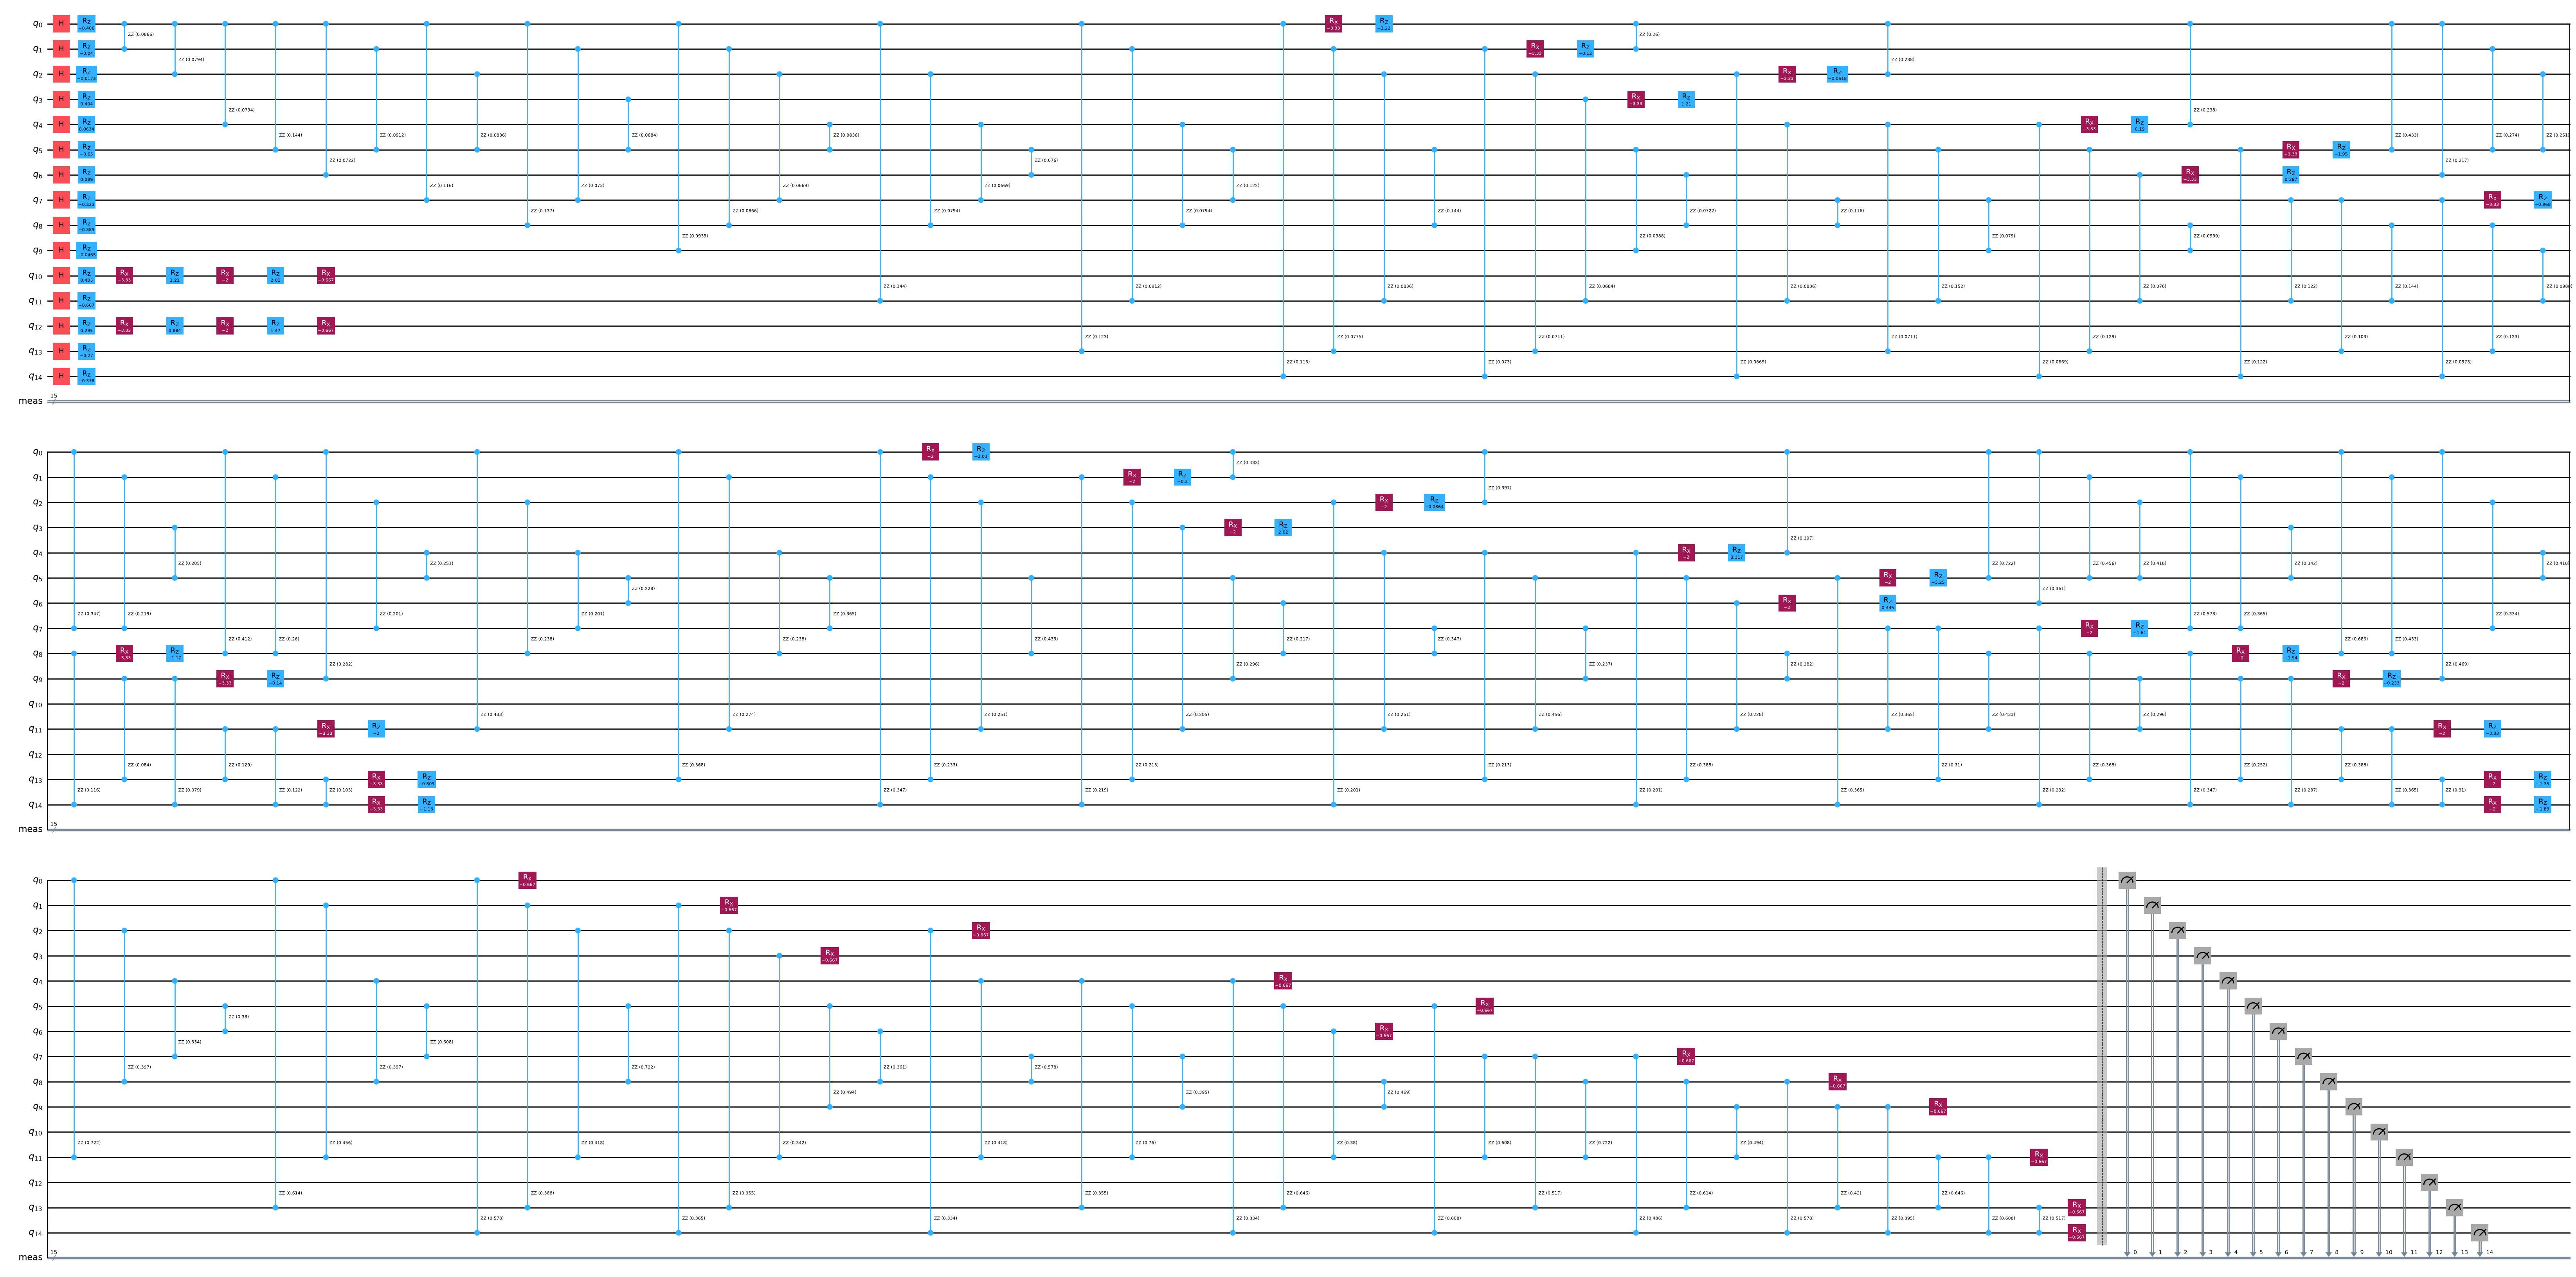

Real backend: ibm_kingston (156 qubits)
basis: ['cz', 'id', 'rx', 'rz', 'rzz', 'sx', 'x']
rzz in basis : True
rzz in target: True

 TRANSPILATION  (noise-aware layout selection)

[A] Seed scan (10 transpiles), top 5 by error:
     rank    err_sum     2q   depth  seed
        1     1.4351    766     893     0
        2     1.4810    768    1054     8
        3     1.5012    813    1047     7
        4     1.5280    782     932     6
        5     1.5442    787     953     4
     best seed error_sum = 1.4351  (worst = 1.6382, i.e. 12% lower)

----------------------------------------------------------------
 method         err_sum  2q gates   depth
----------------------------------------------------------------
 seed-scan       1.4351       766     893
----------------------------------------------------------------
 chosen: seed-scan
 physical qubits used (13): [16, 21, 22, 23, 24, 25, 36, 37, 41, 42, 43, 44, 45]

 logical -> physical qubit map:
   logical  role       physical
         

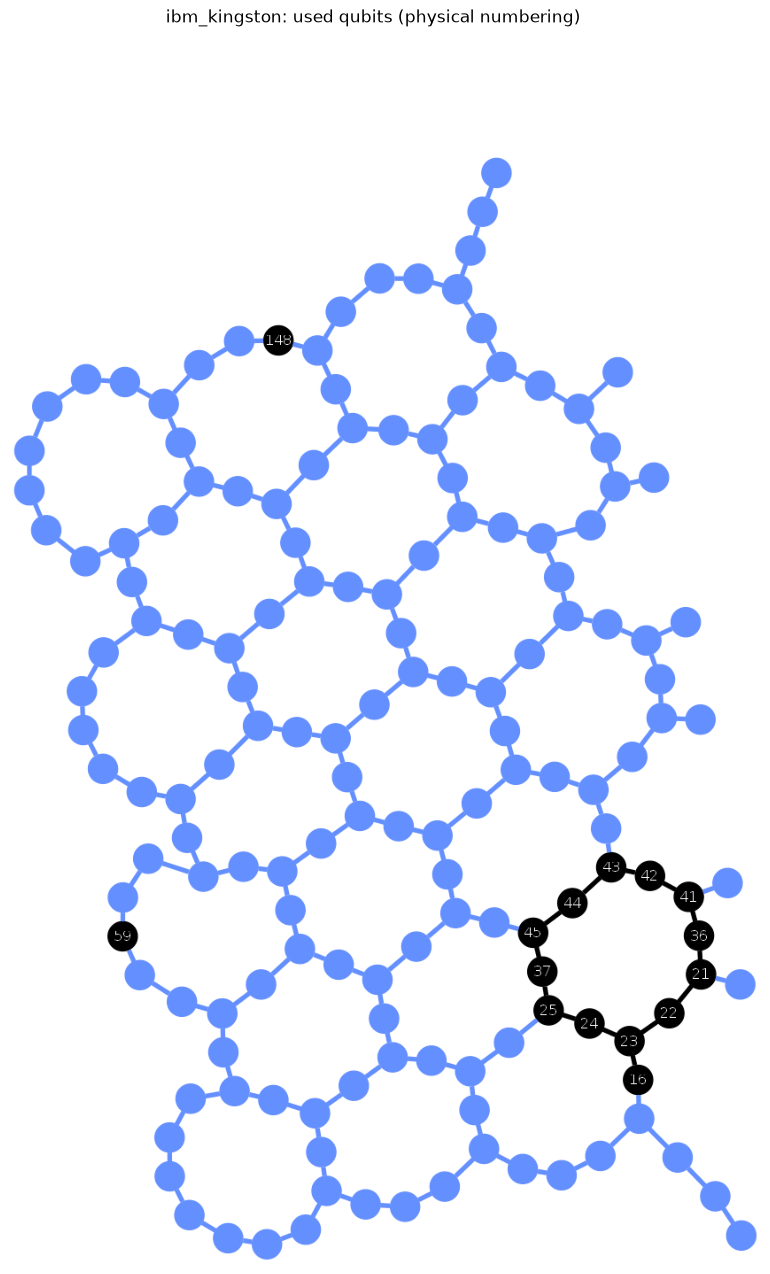

OrderedDict({'sx': 1533, 'rz': 917, 'cz': 766, 'measure': 15, 'x': 12, 'barrier': 1})

Job ID: daasu31l216s739onhrg
 Job ID   : daasu31l216s739onhrg
 Backend  : ibm_kingston
 Started  : 20:59:22
----------------------------------------------------------------
  [→] QUEUED          : 20:59:22
  [←] QUEUED          :    2.3s
  [→] RUNNING         : 20:59:24
  [←] RUNNING         :  112.3s
  [→] DONE            : 21:01:17
  [←] DONE            :    0.0s
----------------------------------------------------------------
 TIME BREAKDOWN:
   QUEUED         :    2.3s (  2.0%)
   RUNNING        :  112.3s ( 97.5%)
   DONE           :    0.0s (  0.0%)

   Billed usage   :   94.0s
   TOTAL WALL     :  115.2s

                    KNAPSACK  -  RESULT SUMMARY
 Backend : ibm_kingston             Logical qubits : 15
 Method  : digitized quantum annealing (no optimizer)
 Layout  : seed-scan   |   2q gates : 766
----------------------------------------------------------------
 Selected items
-------------

In [5]:


ALPHA = 2.0
LAM1  = 6.20 #8.25    # Linear bias
LAM2  = 0.179    # Penalty

STEPS = 3        # shallow anneal (more steps = more decoherence)
T = 6.0
SHOTS           = 300000     # fine on real HW; reduced automatically in DRY_RUN

# ===========================================================================
# 1) QUBO by hand  ->  2) Ising  (x = (1 - Z)/2)
# ===========================================================================
#P = max(values) + 1
#K = CAPACITY.bit_length()
#slack_coeffs = [1 << k for k in range(K - 1)]
#slack_coeffs.append(CAPACITY - (2 ** (K - 1) - 1))     # cap max slack at CAPACITY
#n = N + K
#c = weights + slack_coeffs

#lin, quad = {j: 0.0 for j in range(n)}, {}
#for j in range(n):
#    lin[j] += P * (c[j] ** 2 - 2 * CAPACITY * c[j])
#for i in range(N):
#    lin[i] += -values[i]
#for j in range(n):
#    for l in range(j + 1, n):
#        quad[(j, l)] = 2 * P * c[j] * c[l]

#h, J = {j: 0.0 for j in range(n)}, {}
#for j in range(n):
#    h[j] += -lin[j] / 2
#for (j, l), q in quad.items():
#    h[j] += -q / 4
#    h[l] += -q / 4
#    J[(j, l)] = q / 4

#scale = max(max(abs(v) for v in h.values()), max(abs(v) for v in J.values()))
#h = {j: v / scale for j, v in h.items()}
#J = {k: v / scale for k, v in J.items()}

#n = N                                
#lin = {j: 0.0 for j in range(n)}
#quad = {}
#for i in range(N):    
#    lin[i] += -ALPHA * values[i]    
#    lin[i] +=  LAM1 * weights[i]    
#    lin[i] +=  LAM2 * (weights[i]**2 - 2*CAPACITY*weights[i])
#for i in range(N):    
#    for j in range(i+1, N):        
#        quad[(i, j)] = 2 * LAM2 * weights[i] * weights[j]

n = N                                  
lin = {j: 0.0 for j in range(n)}
for i in range(N):
    lin[i] += -ALPHA * values[i]
    lin[i] +=  LAM1 * weights[i]
    lin[i] +=  LAM2 * (weights[i]**2 - 2*CAPACITY*weights[i])

# start optimum circuit
raw = {}
for i in range(N):
    for j in range(i + 1, N):
        raw[(i, j)] = 2 * LAM2 * weights[i] * weights[j]

if PRUNE_KEEP < 1.0:
    mags = sorted(abs(v) for v in raw.values())
    cut = mags[int((1 - PRUNE_KEEP) * len(mags))]
    quad = {k: v for k, v in raw.items() if abs(v) >= cut}
else:
    quad = dict(raw)
print(f"ZZ gates: stayed {len(quad)}/{len(raw)} "
      f"({100*len(quad)/len(raw):.0f}%)")
# end optimum circuit

_st = np.arange(1 << N); _b = (_st[:, None] >> np.arange(N)) & 1
_V, _W = _b @ np.array(values), _b @ np.array(weights)
_E = -ALPHA*_V + LAM1*_W + LAM2*(_W - CAPACITY)**2
_gs = int(np.argmin(_E))
print(f"ground state of the cost: value={_V[_gs]} weight={_W[_gs]} (cap {CAPACITY}) "
      f"feasible={_W[_gs] <= CAPACITY}")
assert _W[_gs] <= CAPACITY, "penalty is weak - minimum is unacceptable, increase LAM1"


# --- QUBO -> Ising ---
h = {j: 0.0 for j in range(n)}
J = {}
for j in range(n):
    h[j] += -lin[j] / 2
for (j, l), q in quad.items():
    h[j] += -q / 4
    h[l] += -q / 4
    J[(j, l)] = q / 4
scale = max(max(abs(v) for v in h.values()), max(abs(v) for v in J.values()))
h = {j: v / scale for j, v in h.items()}
J = {k: v / scale for k, v in J.items()}
assert all(0 <= j < n and 0 <= l < n for (j, l) in J)

# ===========================================================================
# 3) Digitized quantum annealing (no optimizer)
# ===========================================================================
#STEPS = 3          # ne 1
#T     = 6.0
dt = T / STEPS
qc = QuantumCircuit(n); qc.h(range(n))
for p in range(STEPS):
    s = (p + 0.5) / STEPS          # midpoint - mixer nikdy nespadne na nulu
    t_prob, t_mix = dt * s, dt * (1 - s)
    for j in range(n):
        if h[j]: qc.rz(2 * t_prob * h[j], j)
    for (j, l), Jjl in J.items():
        if Jjl: qc.rzz(2 * t_prob * Jjl, j, l)
    for j in range(n):
        qc.rx(-2 * t_mix, j)
qc.measure_all()
print(f"\nLogical qubits (incl. slack): {n} | raw depth: {qc.depth()}")


def show(fig):
    try:
        shell = get_ipython()
    except NameError:
        shell = None
    if shell is not None:
        from IPython.display import display
        display(fig)
        plt.close(fig)
    else:
        plt.show()


# Diagram of the logical annealing circuit (h, rzz, rx). The circuit is dense
# (all-to-all rzz from the penalty), so it is wide even for small N.
if DRAW_CIRCUIT:
    show(qc.draw("mpl", fold=FOLD, idle_wires=False))

# ===========================================================================
# Backend
# ===========================================================================
if DRY_RUN:
    from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
    backend = FakeSherbrooke()
    print(f"[DRY_RUN] fake backend: {backend.name} ({backend.num_qubits} qubits)")
else:
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n, use_fractional_gates=True)
    print(f"Real backend: {backend.name} ({backend.num_qubits} qubits)")

print("basis:", b.basis_gates)
print("rzz in basis :", "rzz" in b.basis_gates)
print("rzz in target:", "rzz" in b.target.operation_names)

target = backend.target
TWO_Q = [g for g in ("ecr", "cx", "cz", "rzz") if g in target.operation_names] 


def error_score(circ):
    """Sum of 2q-gate + readout errors along the qubits the circuit actually uses
    (lower = better). One consistent metric to compare layouts."""
    s = 0.0
    for instr in circ.data:
        op = instr.operation
        qs = tuple(circ.find_bit(q).index for q in instr.qubits)
        if op.num_qubits == 2 and op.name in TWO_Q:
            pr = target[op.name].get(qs)
            if pr and pr.error is not None:
                s += pr.error
        elif op.name == "measure":
            pr = target["measure"].get(qs)
            if pr and pr.error is not None:
                s += pr.error
    return s


def twoq_count(circ):
    return sum(v for k, v in circ.count_ops().items() if k in TWO_Q)


# ===========================================================================
# 4A) Noise-aware transpile: best-of-K seed scan
# ===========================================================================
print("\n" + "=" * 64)
print(" TRANSPILATION  (noise-aware layout selection)")
print("=" * 64)

scan = []
for seed in range(NUM_TRANSPILES):
    pm = generate_preset_pass_manager(backend=backend, optimization_level=OPT_LEVEL,
                                      seed_transpiler=seed)
    cand = pm.run(qc)
    scan.append((error_score(cand), twoq_count(cand), cand.depth(), seed, cand))
scan.sort(key=lambda r: r[0])

print(f"\n[A] Seed scan ({NUM_TRANSPILES} transpiles), top 5 by error:")
print(f"     {'rank':>4}  {'err_sum':>9}  {'2q':>5}  {'depth':>6}  {'seed':>4}")
for rank, (sc, tq, dp_, sd, _) in enumerate(scan[:5], 1):
    print(f"     {rank:>4}  {sc:>9.4f}  {tq:>5}  {dp_:>6}  {sd:>4}")
isa_seed = scan[0][4]
print(f"     best seed error_sum = {scan[0][0]:.4f}  "
      f"(worst = {scan[-1][0]:.4f}, i.e. {100*(1-scan[0][0]/scan[-1][0]):.0f}% lower)")

candidates = [("seed-scan", isa_seed)]

# ===========================================================================
# 4B) Noise-aware transpile: mapomatic
#     transpile once -> deflate -> score every matching placement on the chip
#     by its error map -> re-transpile onto the best physical qubits.
# ===========================================================================
if USE_MAPOMATIC:
    try:
        import mapomatic as mm
        base = generate_preset_pass_manager(backend=backend, optimization_level=OPT_LEVEL,
                                            seed_transpiler=0).run(qc)
        small = mm.deflate_circuit(base)
        layouts = mm.matching_layouts(small, backend)
        scored = mm.evaluate_layouts(small, layouts, backend)   # sorted, lower = better
        print(f"\n[B] mapomatic: {len(scored)} matching layouts on {backend.name}, "
              f"top 5 by cost:")
        print(f"     {'rank':>4}  {'mm_cost':>9}  physical qubits")
        for rank, (lay, cost) in enumerate(scored[:5], 1):
            print(f"     {rank:>4}  {cost:>9.4f}  {sorted(lay)}")
        best_layout = scored[0][0]
        isa_mm = transpile(small, backend, initial_layout=best_layout,
                           optimization_level=OPT_LEVEL, seed_transpiler=0)
        candidates.append(("mapomatic", isa_mm))
    except Exception as e:
        print(f"\n[B] mapomatic skipped ({e!r})")

# ===========================================================================
# Pick the lowest-error circuit and report the comparison
# ===========================================================================
print("\n" + "-" * 64)
print(f" {'method':<12} {'err_sum':>9} {'2q gates':>9} {'depth':>7}")
print("-" * 64)
for name, circ in candidates:
    print(f" {name:<12} {error_score(circ):>9.4f} {twoq_count(circ):>9} {circ.depth():>7}")
chosen, isa = min(candidates, key=lambda kv: error_score(kv[1]))
print("-" * 64)
print(f" chosen: {chosen}")

phys_qubits = sorted({isa.find_bit(q).index for inst in isa.data
                      for q in inst.qubits if inst.operation.num_qubits == 2})
print(f" physical qubits used ({len(phys_qubits)}): {phys_qubits}")
if twoq_count(isa) > 3000:
    print(" WARNING: >3000 two-qubit gates -> expect noise. Lower N or STEPS.")

# Reconcile the two numbering schemes: the layout plot (view='virtual') would
# label the used qubits 0..n-1 (logical), while the list above is physical.
# Here is exactly which physical qubit each logical qubit (item / slack) runs on.
final_layout = isa.layout.final_index_layout()      # logical k -> physical qubit
print("\n logical -> physical qubit map:")
print(f"   {'logical':>7}  {'role':<10} {'physical':>8}")
for k in range(n):
    role = f"item {k}" if k < N else f"slack {k - N}"
    print(f"   {k:>7}  {role:<10} {final_layout[k]:>8}")

# device-layout picture (the QGSS-style coupling map with used qubits highlighted).
# view='physical' -> the highlighted qubits are labeled with the SAME physical
# numbers printed above (so the map and the log agree).
if MAKE_PLOTS:
    try:
        fig = plot_circuit_layout(isa, backend, view=LAYOUT_VIEW)
        fig.suptitle(f"{backend.name}: used qubits "
                     f"({LAYOUT_VIEW} numbering)")
        show(fig)
    except Exception as e:
        print(f" layout plot skipped ({e!r})")

# Diagram of the transpiled (ISA) circuit - what actually runs on the chip
# (ecr / sx / rz). This is BIG (hundreds of gates); expect a very wide figure.
if DRAW_CIRCUIT:
    try:
        show(isa.draw("mpl", fold=FOLD, idle_wires=False))
    except Exception as e:
        print(f" transpiled diagram skipped ({e!r})")

print(isa.count_ops())
# ===========================================================================
# MONITORING FUNCTION 
# ===========================================================================
def monitor_job(job, poll_interval=10):
    status_times = {}
    current_status = None
    start_time = time.time()
    last_progress = -1

    print(f" Job ID   : {job.job_id()}")
    print(f" Backend  : {job.backend().name if hasattr(job, 'backend') else 'N/A'}")
    print(f" Started  : {time.strftime('%H:%M:%S', time.localtime(start_time))}")
    print("-" * 64)

    FINAL_STATES = {'DONE', 'FAILED', 'CANCELLED'}

    try:
        while True:
            status = job.status()
            now = time.time()

            if status != current_status:
                if current_status is not None:
                    elapsed = now - status_times[current_status]
                    print(f"  [←] {current_status:<15} : {elapsed:>6.1f}s")
                status_times[status] = now
                current_status = status
                print(f"  [→] {status:<15} : {time.strftime('%H:%M:%S', time.localtime(now))}")

            try:
                progress = None
                if hasattr(job, 'progress') and callable(job.progress):
                    progress = job.progress()
                elif hasattr(job, 'percent_complete') and callable(job.percent_complete):
                    progress = job.percent_complete()
                if progress is not None and progress != last_progress:
                    last_progress = progress
                    bar = "█" * int(progress * 20) + " " * (20 - int(progress * 20))
                    print(f"  [▓] Progress: |{bar}| {progress*100:>5.1f}%")
            except Exception:
                pass

            if status in FINAL_STATES:
                elapsed = now - status_times[status]
                print(f"  [←] {status:<15} : {elapsed:>6.1f}s")
                break

            time.sleep(poll_interval)

    except KeyboardInterrupt:
        print("\n  [!] Monitoring stopped by user")

    print("-" * 64)
    print(" TIME BREAKDOWN:")
    total_time = time.time() - start_time
    for state, start in sorted(status_times.items(), key=lambda x: x[1]):
        end = next((v for k, v in status_times.items() if v > start), total_time)
        if state == current_status:
            end = time.time()
        duration = end - start
        pct = 100 * duration / total_time if total_time > 0 else 0
        print(f"   {state:<15}: {duration:>6.1f}s ({pct:>5.1f}%)")

    # --- Billed usage (Pay-As-You-Go only) ---
    try:
        usage = job.usage()
        if usage:
            print(f"\n   {'Billed usage':<15}: {usage:>6.1f}s")
    except Exception:
        pass

    print(f"   {'TOTAL WALL':<15}: {total_time:>6.1f}s")
    print("=" * 64)
    return total_time

# ===========================================================================
# Run
# ===========================================================================
shots = 512 if DRY_RUN else SHOTS
sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.enable_measure = True
job = sampler.run([isa], shots=shots)
print("\nJob ID:", job.job_id())
# --- START MONITORING ---
if not DRY_RUN:
    monitor_job(job, poll_interval=2)  # Check every 2 seconds
counts = job.result()[0].data.meas.get_counts()

# ===========================================================================
# Decode + exact DP
# ===========================================================================
def evaluate(bitstring):
    bits = [int(bitstring[n - 1 - j]) for j in range(n)]
    sel = [i for i in range(N) if bits[i] == 1]
    return sel, sum(weights[i] for i in sel), sum(values[i] for i in sel)

best = None
for bitstring in counts:
    sel, w, v = evaluate(bitstring)
    if w <= CAPACITY and (best is None or v > best[2]):
        best = (sel, w, v)

dp = [0] * (CAPACITY + 1)
for i in range(N):
    for w in range(CAPACITY, weights[i] - 1, -1):
        dp[w] = max(dp[w], dp[w - weights[i]] + values[i])
optimum = dp[CAPACITY]

# ===========================================================================
# Presentation tables
# ===========================================================================
print("\n" + "=" * 64)
print("                    KNAPSACK  -  RESULT SUMMARY")
print("=" * 64)
print(f" Backend : {backend.name:<24} Logical qubits : {n}")
print(f" Method  : digitized quantum annealing (no optimizer)")
print(f" Layout  : {chosen}   |   2q gates : {twoq_count(isa)}")

if best is None:
    print("-" * 64)
    print(" No feasible solution among the samples (result dominated by noise).")
    print("=" * 64)
else:
    sel, w, v = best
    print("-" * 64)
    print(" Selected items")
    print("-" * 64)
    print(f"   {'Item':>6} {'Value':>8} {'Weight':>8}")
    print(f"   {'-'*6} {'-'*8} {'-'*8}")
    for i in sel:
        print(f"   {i:>6} {values[i]:>8} {weights[i]:>8}")
    print(f"   {'-'*6} {'-'*8} {'-'*8}")
    print(f"   {'TOTAL':>6} {v:>8} {w:>8}    (capacity {CAPACITY})")
    print("-" * 64)
    print(" Solution quality")
    print("-" * 64)
    print(f"   {'Method':<22} {'Value':>7} {'% of optimum':>14}")
    print(f"   {'-'*22} {'-'*7} {'-'*14}")
    print(f"   {'Quantum (hardware)':<22} {v:>7} {100*v/optimum:>13.1f}%")
    print(f"   {'Exact (dynamic prog.)':<22} {optimum:>7} {'-':>14}")
    print("=" * 64)

In [10]:
# =========================================================================
#  VÝSLEDKY: prob + TAB  (spouštět až po buňce, která vytvoří `counts`)
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

GOOD  = 0.90     # modrá = do 10 % od optima
TOP_K = 300       # kolik nejpravděpodobnějších bitstringů vykreslit

# --- optimum (DP) --------------------------------------------------------
try:
    OPT = optimum
except NameError:
    _dp = [0] * (CAPACITY + 1)
    for i in range(N):
        for _w in range(CAPACITY, weights[i] - 1, -1):
            _dp[_w] = max(_dp[_w], _dp[_w - weights[i]] + values[i])
    OPT = _dp[CAPACITY]

# --- prob[i] = P(kombinace položek i);  bit j = položka j ----------------
SIZE = 1 << N
SHOTS_TOT = sum(counts.values())
prob = np.zeros(SIZE)
for _bs, _c in counts.items():
    prob[int(_bs, 2) & (SIZE - 1)] += _c / SHOTS_TOT   # spodních N bitů = položky

# --- TAB: hodnota / váha / přípustnost pro všech 2^N kombinací -----------
_states = np.arange(SIZE)
_bits   = (_states[:, None] >> np.arange(N)) & 1
_tot_v  = _bits @ np.array(values)
_tot_w  = _bits @ np.array(weights)
_feas   = _tot_w <= CAPACITY
TAB = {
    "tot_v": _tot_v,
    "tot_w": _tot_w,
    "feas":  _feas,
    "good":  _feas & (_tot_v >= GOOD * OPT),
    "masks": set(np.flatnonzero(_feas & (_tot_v == OPT)).tolist()),
}

print(f"OPT = {OPT}   optimal bitstrings: {len(TAB['masks'])}")
print(f"P(feasible) = {prob[TAB['feas']].sum():.4f}   "
      f"P(optimum)  = {prob[sorted(TAB['masks'])].sum():.4f}   "
      f"P(within {100*(1-GOOD):.0f}%) = {prob[TAB['good']].sum():.4f}")

OPT = 272   optimal bitstrings: 1
P(feasible) = 0.1263   P(optimum)  = 0.0002   P(within 10%) = 0.0037


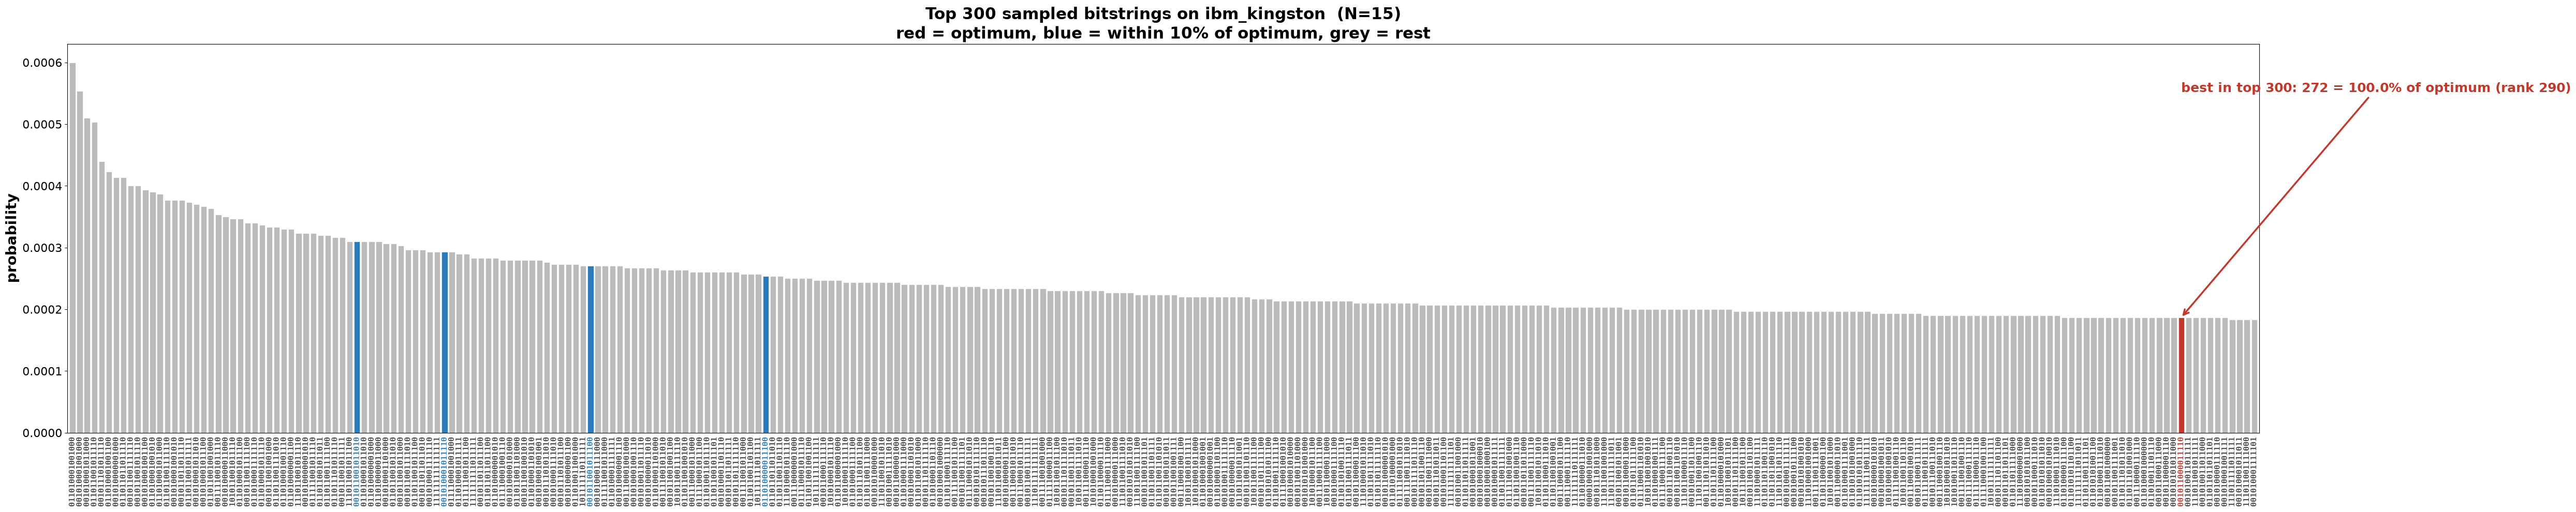

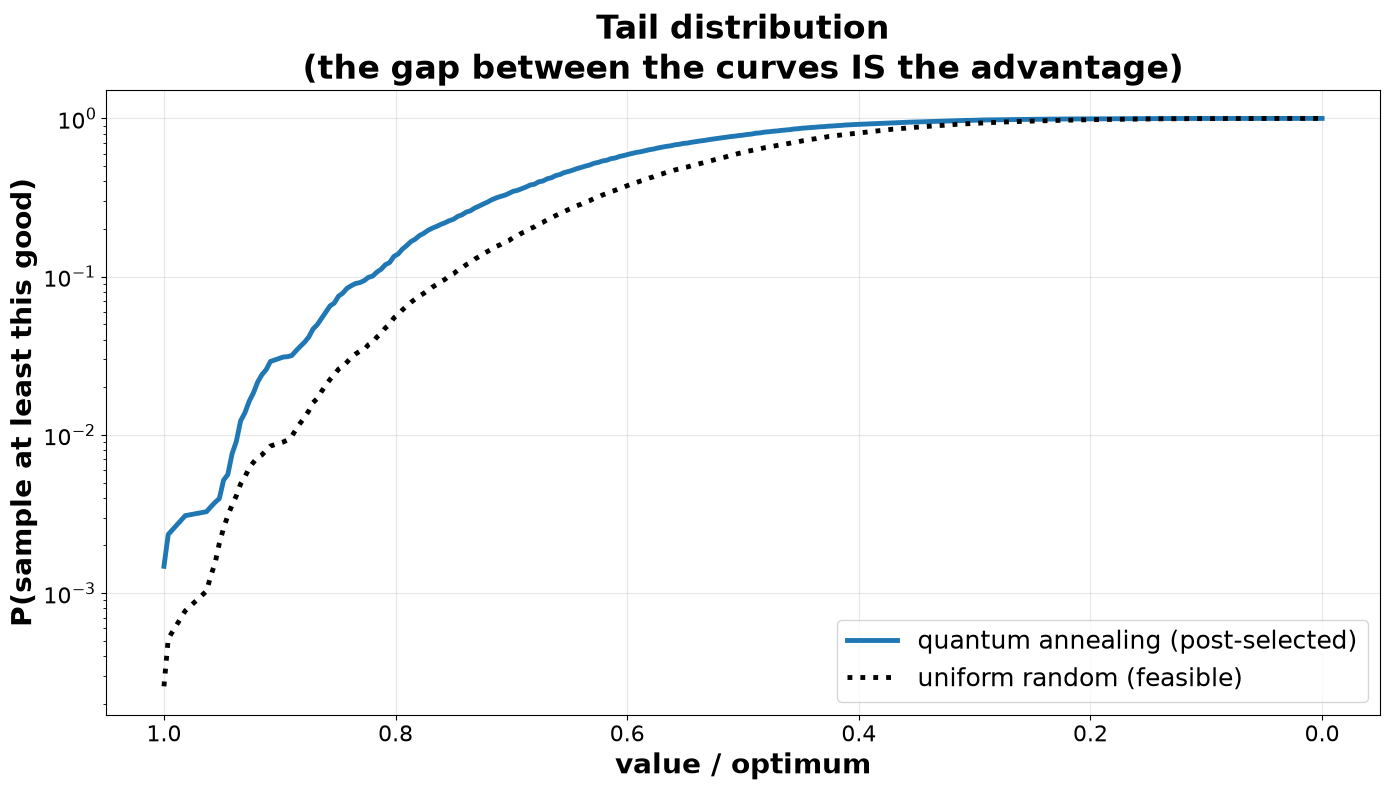

In [11]:
order = np.argsort(-prob)[:TOP_K]
order = order[prob[order] > 0]                # nekreslit nulové sloupce

# ===================== GRAF 1 - bitstringy (na šířku) ====================
FIG_W = float(np.clip(0.30 * len(order), 14, 50))
fig1, ax = plt.subplots(figsize=(FIG_W, 10))
col = ["#c0392b" if i in TAB["masks"] else ("#2b7bba" if TAB["good"][i] else "#bbb")
       for i in order]
ax.bar(range(len(order)), prob[order], color=col, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([format(i, f"0{N}b") for i in order],
                   rotation=90, fontsize=11, fontweight="bold", fontfamily="monospace")
for lbl, c in zip(ax.get_xticklabels(), col):
    lbl.set_color(c if c != "#bbb" else "#444")
ax.tick_params(axis="x", length=0, pad=6)
ax.tick_params(axis="y", labelsize=16)
ax.set_xlim(-0.7, len(order) - 0.3)
ax.set_ylabel("probability", fontsize=20, fontweight="bold")

# nejlepší přípustné řešení mezi zobrazenými + jeho pořadí
feas_in_view = [(r, i) for r, i in enumerate(order) if TAB["feas"][i]]
if feas_in_view:
    best_rank, bi = max(feas_in_view, key=lambda t: TAB["tot_v"][t[1]])
    ax.annotate(f"best in top {len(order)}: {int(TAB['tot_v'][bi])} = "
                f"{100*TAB['tot_v'][bi]/OPT:.1f}% of optimum (rank {best_rank+1})",
                xy=(best_rank, prob[bi]),
                xytext=(best_rank, prob[order].max() * 0.92),
                fontsize=18, fontweight="bold", ha="left", color="#c0392b",
                arrowprops=dict(arrowstyle="->", lw=2.5, color="#c0392b"))
ax.set_title(f"Top {len(order)} sampled bitstrings on {backend.name}  (N={N})\n"
             f"red = optimum, blue = within {100*(1-GOOD):.0f}% of optimum, grey = rest",
             fontsize=22, fontweight="bold")
plt.tight_layout()
fig1.savefig("bitstrings.png", dpi=110, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 8))
vals_sorted = np.unique(TAB["tot_v"][TAB["feas"]])[::-1]
p_feas = prob[TAB["feas"]].sum()
cum_q = [prob[TAB["feas"] & (TAB["tot_v"] >= v)].sum() / p_feas for v in vals_sorted]
cum_r = [(TAB["feas"] & (TAB["tot_v"] >= v)).sum() / TAB["feas"].sum() for v in vals_sorted]
ax2.plot(vals_sorted / OPT, cum_q, lw=3.5, label="quantum annealing (post-selected)")
ax2.plot(vals_sorted / OPT, cum_r, "k:", lw=3.5, label="uniform random (feasible)")
ax2.set_xlabel("value / optimum", fontsize=20, fontweight="bold")
ax2.set_ylabel("P(sample at least this good)", fontsize=20, fontweight="bold")
ax2.tick_params(labelsize=16)
ax2.set_yscale("log"); ax2.invert_xaxis()
ax2.set_title("Tail distribution\n(the gap between the curves IS the advantage)",
              fontsize=24, fontweight="bold")
ax2.legend(fontsize=18); ax2.grid(alpha=.3)
plt.tight_layout()
fig2.savefig("tail.png", dpi=110, bbox_inches="tight")
plt.show()

# **Knapsack — Result Summary**

---

**Backend:** `ibm_fez` &nbsp;|&nbsp; **Logical qubits:** **15**
**Method:** digitized quantum annealing (no optimizer)
**Layout:** seed-scan &nbsp;|&nbsp; **2-qubit gates:** **130**

### **Selected items**

| **Item** | **Value** | **Weight** |
|:--------:|:---------:|:----------:|
| 0        | 45        | 14         |
| 1        | 12        | 2          |
| 2        | 6         | 1          |
| 3        | 52        | 3          |
| 5        | 20        | 8          |
| 8        | 52        | 1          |
| 10       | 48        | 7          |
| 14       | 42        | 15         |
| **TOTAL** | **277**  | **51**     |

> **Total value: 277** &nbsp;·&nbsp; **Total weight: 51 / capacity 51** (exactly full)

### **Solution quality**

| **Method** | **Value** | **% of optimum** |
|:-----------|:---------:|:----------------:|
| Quantum (hardware)     | **277** | **99.3 %** |
| Exact (dynamic prog.)  | 279     | —          |

**The quantum run reached 277 out of the exact optimum of 279 — just 2 short, at 99.3 % of optimum, while staying exactly within capacity.**

